In [36]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [37]:
df = pd.read_csv(
    "../data/processed/multilingual_sentiment_cleaned.csv"
)

df.head()

,text,sentiment,language,cleaned_text
0,"Next date - Birmingham, The Rainbow, Sun 7th J...",Positive,English,next date birmingham the rainbow sun th june s...
1,Action king dialogue semma..... avanoda sindh...,Positive,Tamil,action king dialogue semma avanoda sindhanayum...
2,"Appedilaam nadekaathu, nadake kudaathu!! The ...",Positive,Tamil,appedilaam nadekaathu nadake kudaathu the bull...
3,Looks like d Mixture of Kaala+Kabali..... ...,Positive,Tamil,looks like d mixture of kaalakabali sure antho...
4,Nfg greatest hits cd cracked,Negative,English,nfg greatest hits cd cracked


In [38]:
df["label"] = df["sentiment"].map({
    "Negative": 0,
    "Positive": 1
})

In [39]:
X = df["cleaned_text"]

y = df["label"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [41]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

Model 1 — Logistic Regression

In [42]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr.predict(
    X_test_tfidf
)

In [43]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",
      f1_score(y_test, lr_pred))

Accuracy: 0.78921885087153
Precision: 0.8012884043607532
Recall: 0.8651685393258427
F1: 0.8320041162850528


In [44]:
print(
    classification_report(
        y_test,
        lr_pred
    )
)

              precision    recall  f1-score   support

           0       0.77      0.67      0.72      2458
           1       0.80      0.87      0.83      3738

    accuracy                           0.79      6196
   macro avg       0.78      0.77      0.77      6196
weighted avg       0.79      0.79      0.79      6196



In [45]:
print(
    confusion_matrix(
        y_test,
        lr_pred
    )
)

[[1656  802]
 [ 504 3234]]


Model 2 — Multinomial Naive Bayes

In [46]:
nb = MultinomialNB()

nb.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb.predict(
    X_test_tfidf
)

In [47]:
print("Accuracy:",
      accuracy_score(y_test, nb_pred))

print("Precision:",
      precision_score(y_test, nb_pred))

print("Recall:",
      recall_score(y_test, nb_pred))

print("F1:",
      f1_score(y_test, nb_pred))

Accuracy: 0.7729180116204003
Precision: 0.8278481012658228
Recall: 0.7873194221508828
F1: 0.807075277663513


Model 3 — Linear SVM

In [48]:
svm = LinearSVC(
    random_state=42
)

svm.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm.predict(
    X_test_tfidf
)

In [49]:
print("Accuracy:",
      accuracy_score(y_test, svm_pred))

print("Precision:",
      precision_score(y_test, svm_pred))

print("Recall:",
      recall_score(y_test, svm_pred))

print("F1:",
      f1_score(y_test, svm_pred))

Accuracy: 0.7709812782440284
Precision: 0.7981486243250193
Recall: 0.8303905831995719
F1: 0.8139504392290546


Model Comparison Table

In [50]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, nb_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, nb_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, nb_pred),
        f1_score(y_test, svm_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.789219,0.801288,0.865169,0.832004
1,Naive Bayes,0.772918,0.827848,0.787319,0.807075
2,Linear SVM,0.770981,0.798149,0.830391,0.813950


In [51]:
results.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

In [52]:
import joblib

joblib.dump(
    lr,
    "../models/logistic_regression_model.pkl"
)

print("Best model saved successfully")

Best model saved successfully


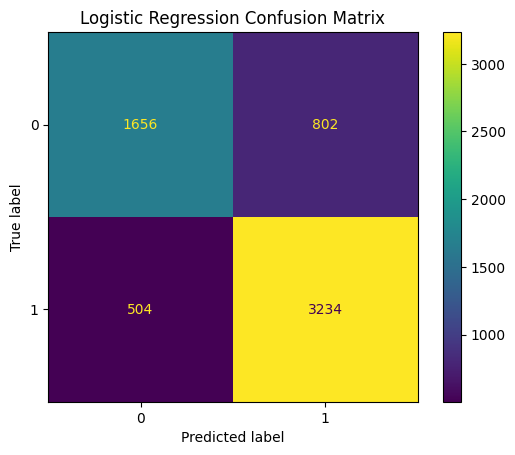

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

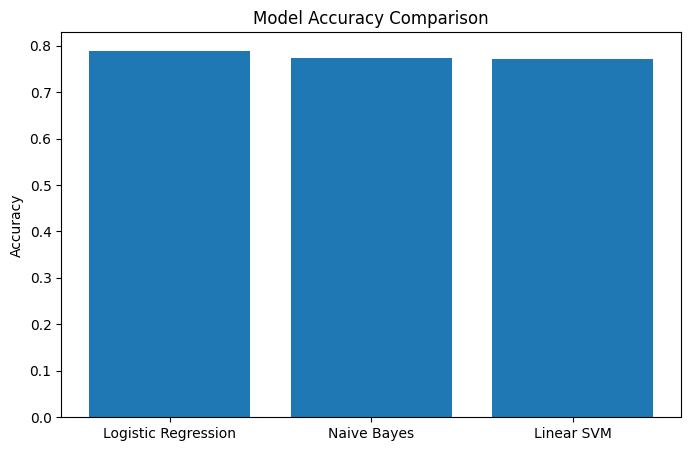

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

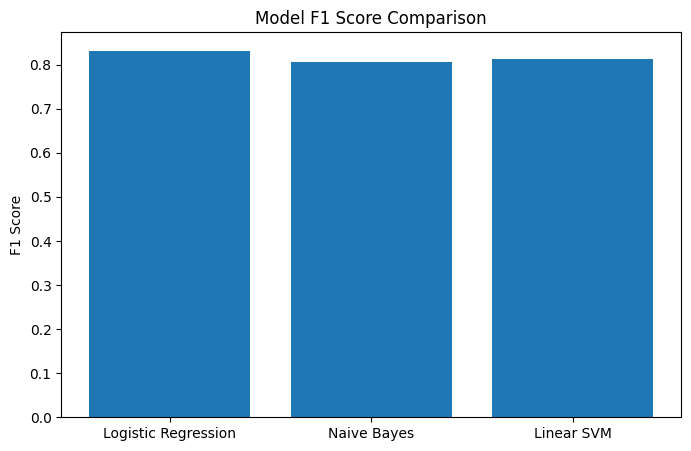

In [55]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")

plt.show()

MODEL TRAINING SUMMARY

Models Evaluated:
1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM

Best Model:
Logistic Regression

Accuracy:
78.08%

Precision:
80.25%

Recall:
86.67%

F1 Score:
83.34%

Model Saved:
models/logistic_regression_model.pkl